# Assignment 3 — Association Rule Mining

**Dataset:** `bread_basket.csv` (9,465 unique transactions; 20,507 item rows)

Fill in the short answer cells and run the code cells. This notebook generates the required tables and figures.

**Sections:**
1. Setup & Data Load
2. EDA (a–e)
3. Frequent Itemset Mining (FP-Growth)
4. Association Rules + Report Table
5. Rule Subgraph (Bread, Coffee, Cake, Tea)
6. Interpretation Prompt


**Student:** Jackson Moody

Completed using the full dataset and the Lecture 6 workflow. Duplicate item rows do not count as separate transactions or multiple occurrences in the one-hot matrix.

## 1) Setup & Data Load (10 pts)
- Place `bread_basket.csv` in the same folder as this notebook **or** update the path below.
- Needed packages: `pandas`, `matplotlib`, `mlxtend`, `networkx` (for the small graph).
- If a package is missing, run the `pip install` cell.

In [1]:
# Install missing packages only; safe to rerun in Jupyter or Google Colab.
import importlib.util
import subprocess
import sys
packages = ['pandas', 'matplotlib', 'mlxtend', 'networkx']
missing = [p for p in packages if importlib.util.find_spec(p) is None]
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing])

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import display
from mlxtend.frequent_patterns import fpgrowth, association_rules
%matplotlib inline

# Accept both the assignment filename and the uploaded filename.
paths = [Path('bread_basket.csv'), Path('bread_basket-2.csv')]
CSV_PATH = next((path for path in paths if path.is_file()), None)
if CSV_PATH is None:
    raise FileNotFoundError('Place bread_basket.csv or bread_basket-2.csv beside this notebook.')
bread = pd.read_csv(CSV_PATH)
print(f'Loaded {CSV_PATH}: {len(bread):,} item rows, '
      f'{bread["transaction"].nunique():,} unique transactions, '
      f'{bread["item"].nunique():,} items.')
display(bread.head())

No event loop hook running.
Loaded bread_basket-2.csv: 20,507 item rows, 9,465 unique transactions, 94 items.


,transaction,item,date_time,time,period_day,weekday_weekend
0,1,Bread,30/10/2016,9:58,morning,weekend
1,2,Scandinavian,30/10/2016,10:05,morning,weekend
2,2,Scandinavian,30/10/2016,10:05,morning,weekend
3,3,Hot chocolate,30/10/2016,10:07,morning,weekend
4,3,Jam,30/10/2016,10:07,morning,weekend


## 2) EDA (a–e) (30 pts)
### a) List variables and their dtypes (5 pts)

In [2]:
display(bread.dtypes.rename('dtype').to_frame())
print('Each row represents an item recorded within a transaction. date_time and time are strings as loaded.')

Each row represents an item recorded within a transaction. date_time and time are strings as loaded.


,dtype
transaction,int64
item,str
date_time,str
time,str
period_day,str
weekday_weekend,str


### b) "Statistics" overview (5 pts)
Use `describe(include='all')` as a stand‑in for Statistics.

In [3]:
display(bread.describe(include='all'))
print('Transaction IDs are identifiers; their mean and standard deviation have no sales interpretation.')

Transaction IDs are identifiers; their mean and standard deviation have no sales interpretation.


,transaction,item,date_time,time,period_day,weekday_weekend
count,20507.000000,20507,20507,20507,20507,20507
unique,NaN,94,159,1255,4,2
top,NaN,Coffee,2017-02-04,11:06,afternoon,weekday
freq,NaN,5471,292,52,11569,12807
mean,4976.202370,NaN,NaN,NaN,NaN,NaN
std,2796.203001,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2552.000000,NaN,NaN,NaN,NaN,NaN
50%,5137.000000,NaN,NaN,NaN,NaN,NaN
75%,7357.000000,NaN,NaN,NaN,NaN,NaN


### c) Bar plot — count of **unique transactions per item** (10 pts)
Set the subtitle to your **FirstName LastName**.

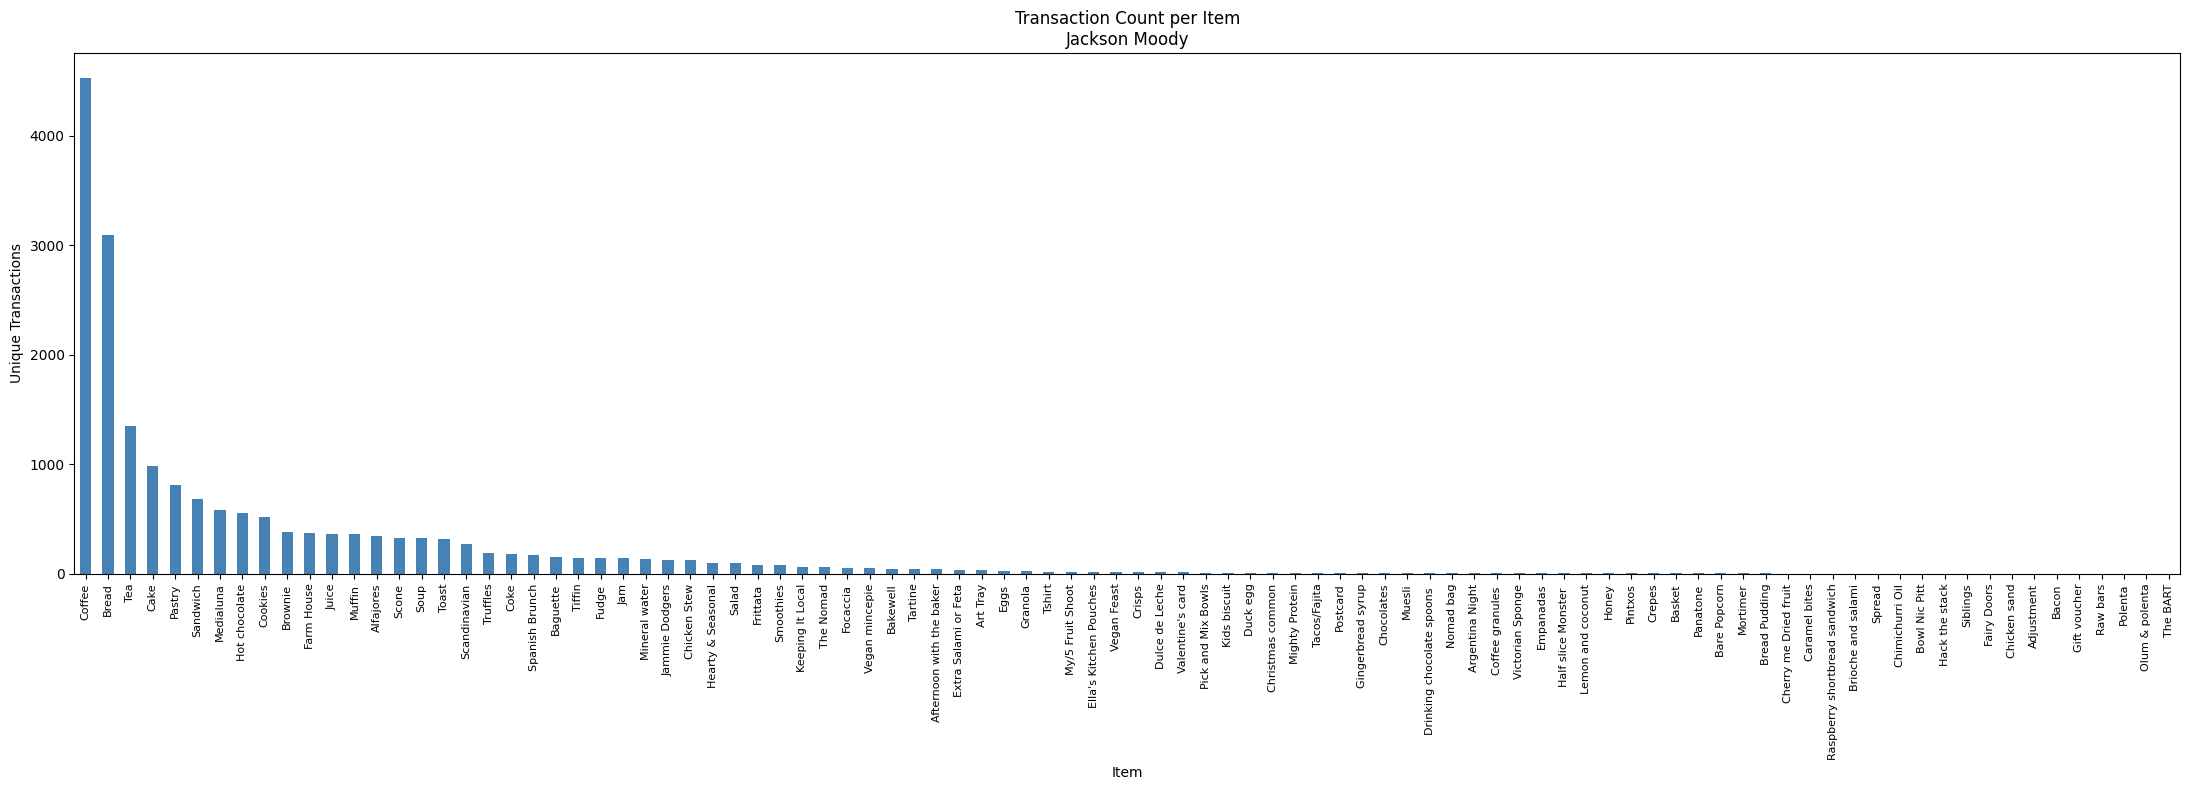

In [4]:
subtitle = 'Jackson Moody'
item_counts = bread.groupby('item')['transaction'].nunique().sort_values(ascending=False)
ax = item_counts.plot(kind='bar', figsize=(22, 8), color='steelblue')
ax.set_title(f'Transaction Count per Item\n{subtitle}')
ax.set_xlabel('Item')
ax.set_ylabel('Unique Transactions')
ax.tick_params(axis='x', labelsize=8)
plt.tight_layout()
plt.show()

### d) Report counts for Coffee, Tea, Alfajores, Juice, and Chicken Stew (10 pts)

In [5]:
requested_items = ['Coffee', 'Tea', 'Alfajores', 'Juice', 'Chicken Stew']
display(item_counts.reindex(requested_items).rename('Unique transactions').to_frame())

,Unique transactions
item,
Coffee,4528
Tea,1350
Alfajores,344
Juice,365
Chicken Stew,123


### e) Data quality and basket overview
The rubric mentions EDA (a–e), but the provided template supplies only (a–d). This additional overview checks missing values, duplicate records, basket sizes, and the date range. Repeated item records are retained in the original data and counted once per transaction for association mining.

In [6]:
display(bread.isna().sum().rename('Missing values').to_frame())
print(f'Exact duplicate rows: {bread.duplicated().sum():,}')
print(f'Repeated transaction-item rows: {bread.duplicated(["transaction", "item"]).sum():,}')
basket_sizes = bread.groupby('transaction')['item'].nunique()
display(basket_sizes.describe().rename('Unique items per basket').to_frame())
# Parse the two supplied formats explicitly to avoid swapping ISO months and days.
iso = bread['date_time'].str.contains('-', regex=False)
dates = pd.Series(index=bread.index, dtype='datetime64[ns]')
dates.loc[iso] = pd.to_datetime(bread.loc[iso, 'date_time'], format='%Y-%m-%d', errors='raise')
dates.loc[~iso] = pd.to_datetime(bread.loc[~iso, 'date_time'], format='%d/%m/%Y', errors='raise')
print(f'Date range: {dates.min().date()} to {dates.max().date()}')
print(f'Coffee base rate: {item_counts["Coffee"] / bread["transaction"].nunique():.2%}')

Exact duplicate rows: 1,620
Repeated transaction-item rows: 1,620
Date range: 2016-10-30 to 2017-04-09
Coffee base rate: 47.84%


,Missing values
transaction,0
item,0
date_time,0
time,0
period_day,0
weekday_weekend,0


,Unique items per basket
count,9465.000000
mean,1.995457
std,1.129543
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,10.000000


## 3) Frequent Itemset Mining with FP‑Growth (min_support = 0.02) (25 pts)
We pivot the data to a **transaction × item** one‑hot table (boolean), then run FP‑Growth.

In [7]:
# One True value indicates that the item appears at least once in a basket.
# crosstab collapses duplicate item records before the boolean conversion.
one_hot = pd.crosstab(bread['transaction'], bread['item']).gt(0)
MIN_SUPPORT = 0.02
frequent_itemsets = fpgrowth(one_hot, min_support=MIN_SUPPORT, use_colnames=True)
frequent_itemsets['itemset_length'] = frequent_itemsets['itemsets'].map(len)
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False).reset_index(drop=True)
itemset_report = frequent_itemsets.copy()
itemset_report['itemsets'] = itemset_report['itemsets'].map(lambda s: '{' + ', '.join(sorted(s)) + '}')
itemset_report['transaction_count'] = (itemset_report['support'] * len(one_hot)).round().astype(int)
print(f'One-hot shape: {one_hot.shape}; all columns boolean: {one_hot.dtypes.eq(bool).all()}')
print(f'{len(frequent_itemsets)} frequent itemsets at support >= {MIN_SUPPORT:.0%}.')
display(one_hot.head())
display(itemset_report[['itemsets', 'itemset_length', 'transaction_count', 'support']])

One-hot shape: (9465, 94); all columns boolean: True
33 frequent itemsets at support >= 2%.


item,Adjustment,Afternoon with the baker,Alfajores,Argentina Night,Art Tray,Bacon,Baguette,Bakewell,Bare Popcorn,Basket,Bowl Nic Pitt,Bread,Bread Pudding,Brioche and salami,Brownie,Cake,Caramel bites,Cherry me Dried fruit,Chicken Stew,Chicken sand,Chimichurri Oil,Chocolates,Christmas common,Coffee,Coffee granules,Coke,Cookies,Crepes,Crisps,Drinking chocolate spoons,Duck egg,Dulce de Leche,Eggs,Ella's Kitchen Pouches,Empanadas,Extra Salami or Feta,Fairy Doors,Farm House,Focaccia,Frittata,...,Lemon and coconut,Medialuna,Mighty Protein,Mineral water,Mortimer,Muesli,Muffin,My/5 Fruit Shoot,Nomad bag,Olum & polenta,Panatone,Pastry,Pick and Mix Bowls,Pintxos,Polenta,Postcard,Raspberry shortbread sandwich,Raw bars,Salad,Sandwich,Scandinavian,Scone,Siblings,Smoothies,Soup,Spanish Brunch,Spread,Tacos/Fajita,Tartine,Tea,The BART,The Nomad,Tiffin,Toast,Truffles,Tshirt,Valentine's card,Vegan Feast,Vegan mincepie,Victorian Sponge
transaction,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


,itemsets,itemset_length,transaction_count,support
0,{Coffee},1,4528,0.478394
1,{Bread},1,3097,0.327205
2,{Tea},1,1350,0.142631
3,{Cake},1,983,0.103856
4,"{Bread, Coffee}",2,852,0.090016
5,{Pastry},1,815,0.086107
6,{Sandwich},1,680,0.071844
7,{Medialuna},1,585,0.061807
8,{Hot chocolate},1,552,0.058320
9,"{Cake, Coffee}",2,518,0.054728


## 4) Association Rules + Report Table (25 pts)
Generate rules using confidence with **min_threshold = 0.20**. A 20% threshold gives a manageable report of 13 rules and retains relationships involving Bread, Coffee, Cake, and Tea for the subgraph. This is an exploratory choice, not proof that each rule is useful. Evaluate lift against 1 and consider the consequent's base rate before recommending a promotion. Support and confidence are proportions from 0 to 1.

In [8]:
MIN_CONFIDENCE = 0.20
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=MIN_CONFIDENCE)
rules = rules.sort_values(['lift', 'confidence', 'support'], ascending=False).reset_index(drop=True)
report = rules[['antecedents', 'consequents', 'antecedent support', 'consequent support',
                'support', 'confidence', 'lift']].copy()
for col in ['antecedents', 'consequents']:
    report[col] = report[col].map(lambda s: '{' + ', '.join(sorted(s)) + '}')
report.insert(2, 'transaction_count', (report['support'] * len(one_hot)).round().astype(int))
print(f'{len(report)} rules with confidence >= {MIN_CONFIDENCE:.0%}.')
display(report.round(4))

13 rules with confidence >= 20%.


,antecedents,consequents,transaction_count,antecedent support,consequent support,support,confidence,lift
0,{Cake},{Tea},225,0.1039,0.1426,0.0238,0.2289,1.6048
1,{Toast},{Coffee},224,0.0336,0.4784,0.0237,0.7044,1.4724
2,{Medialuna},{Coffee},333,0.0618,0.4784,0.0352,0.5692,1.1899
3,{Pastry},{Coffee},450,0.0861,0.4784,0.0475,0.5521,1.1542
4,{Juice},{Coffee},195,0.0386,0.4784,0.0206,0.5342,1.1167
5,{Sandwich},{Coffee},362,0.0718,0.4784,0.0382,0.5324,1.1128
6,{Cake},{Coffee},518,0.1039,0.4784,0.0547,0.5270,1.1015
7,{Cookies},{Coffee},267,0.0544,0.4784,0.0282,0.5184,1.0837
8,{Hot chocolate},{Coffee},280,0.0583,0.4784,0.0296,0.5072,1.0603
9,{Pastry},{Bread},276,0.0861,0.3272,0.0292,0.3387,1.0350


## 5) Rule Subgraph (Bread, Coffee, Cake, Tea) (5 pts)
Filter the mined rules to antecedents and consequents entirely within the four requested items. Arrows show the rule direction. Edge labels show confidence (C) and lift (L). All four items are shown even if a threshold leaves an item without an edge.

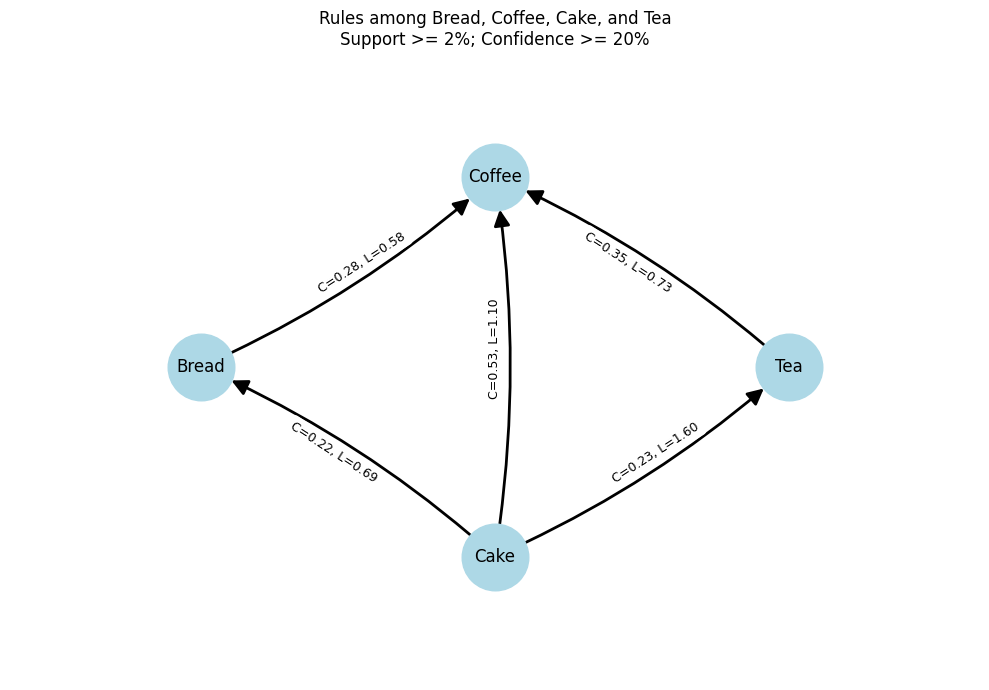

,antecedents,consequents,transaction_count,antecedent support,consequent support,support,confidence,lift
0,{Cake},{Tea},225,0.103856,0.142631,0.023772,0.228891,1.604781
1,{Cake},{Coffee},518,0.103856,0.478394,0.054728,0.526958,1.101515
2,{Tea},{Coffee},472,0.142631,0.478394,0.049868,0.349630,0.730840
3,{Cake},{Bread},221,0.103856,0.327205,0.023349,0.224822,0.687097
4,{Bread},{Coffee},852,0.327205,0.478394,0.090016,0.275105,0.575059


In [9]:
focus = {'Bread', 'Coffee', 'Cake', 'Tea'}
sub = rules[rules['antecedents'].map(lambda s: s.issubset(focus)) &
            rules['consequents'].map(lambda s: s.issubset(focus))].copy()
G = nx.DiGraph()
G.add_nodes_from(sorted(focus))
for _, row in sub.iterrows():
    a = ', '.join(sorted(row['antecedents']))
    b = ', '.join(sorted(row['consequents']))
    G.add_edge(a, b, confidence=float(row['confidence']), lift=float(row['lift']))
# Fixed positions make the four-item view easy to reproduce.
pos = {'Coffee': (0, 1), 'Bread': (-1, 0), 'Cake': (0, -1), 'Tea': (1, 0)}
if set(G.nodes) != focus:
    pos = nx.spring_layout(G, seed=0)
fig, ax = plt.subplots(figsize=(10, 7))
nx.draw_networkx_nodes(G, pos, node_size=2300, node_color='lightblue', ax=ax)
nx.draw_networkx_labels(G, pos, font_size=12, ax=ax)
nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=24, node_size=2300,
                       width=2, connectionstyle='arc3,rad=0.08', ax=ax)
labels = {(a, b): f'C={d["confidence"]:.2f}, L={d["lift"]:.2f}' for a, b, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_size=9,
                            label_pos=0.55, ax=ax)
ax.set_title('Rules among Bread, Coffee, Cake, and Tea\nSupport >= 2%; Confidence >= 20%')
ax.margins(0.25)
ax.set_axis_off()
plt.tight_layout()
plt.show()
display(report.loc[sub.index].reset_index(drop=True))

## 6) Interpretation (5 pts)
**Interpret the rule `{Coffee, Cake} ⇒ {Bread}` in plain English.**

- **Support**: What fraction of *all* transactions contain Coffee, Cake, and Bread together?
- **Confidence**: Among baskets with Coffee and Cake, what share also include Bread?
- **Lift > 1** implies positive association; comment on practical meaning.

The rule is evaluated directly below because its support is below the 2% mining threshold.

In [10]:
antecedent = one_hot[['Coffee', 'Cake']].all(axis=1)
consequent = one_hot['Bread']
joint = antecedent & consequent
support = joint.mean()
confidence = joint.sum() / antecedent.sum()
lift = confidence / consequent.mean()
display(pd.DataFrame([{
    'Rule': '{Coffee, Cake} => {Bread}', 'Joint transactions': int(joint.sum()),
    'Antecedent transactions': int(antecedent.sum()), 'Total transactions': len(one_hot),
    'support': support, 'confidence': confidence, 'Bread base rate': consequent.mean(), 'lift': lift
}]))
print(f'Support: {support:.4%}; confidence: {confidence:.4%}; lift: {lift:.4f}')
print(f'Included at 2% support? {support >= MIN_SUPPORT}')

Support: 1.0037%; confidence: 18.3398%; lift: 0.5605
Included at 2% support? False


,Rule,Joint transactions,Antecedent transactions,Total transactions,support,confidence,Bread base rate,lift
0,"{Coffee, Cake} => {Bread}",95,518,9465,0.010037,0.183398,0.327205,0.560497


The rule means: when a basket contains both Coffee and Cake, it may also contain Bread. All three items occur in **95 of 9,465 transactions**, so support is **1.0037%**. Coffee and Cake occur together in 518 baskets, and 95 also include Bread, giving confidence of **18.3398%**. Bread's overall base rate is **32.7205%**, so lift is **0.5605** (18.3398% divided by 32.7205%).

Lift greater than 1 would indicate a positive association: Bread would be more common among Coffee-and-Cake baskets than in all baskets. Here, lift is below 1, so Bread is less common in those baskets. These results do not support a three-item bundle based on positive association alone. A promotion would need testing and consideration of margins and customer demand; association does not establish causation.

This triple is excluded from FP-Growth results at min_support = 0.02 because its support is about 0.01. It is computed separately to answer the requested interpretation without changing the required mining threshold.